# Bulk RNA-seq Data Analysis Workflow in Python

Prepare your libraries

In [1]:
!pip install pandas numpy seaborn matplotlib scikit-learn pydeseq2

## Import Required Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import zscore
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

## Load the Count Data

In [3]:

if not os.path.exists("data/kallisto.merged.gene_counts.tsv"):

    !mkdir -p data;

    !cd data; wget https://github.com/BMGLab/CrashCourses/raw/refs/heads/main/data/kallisto.merged.gene_counts.tsv.gz

    !gunzip data/kallisto.merged.gene_counts.tsv.gz
    !mkdir -p write

if not os.path.exists("data/SraRunTable_SRP428267.csv"):
    !cd data; wget https://raw.githubusercontent.com/BMGLab/CrashCourses/refs/heads/main/SraRunTable_SRP428267.csv


In [4]:
meta_data = pd.read_csv("data/SraRunTable_SRP428267.csv", index_col=0)
meta_data.head()

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_type,Center Name,Collection_Date,Consent,...,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,tissue,treatment,type
Run,,,,,,,,,,,,,,,,,,,,,
SRR23920135,RNA-Seq,300,17246491200,PRJNA946733,SAMN33830924,5485957628,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:13:00Z,1,GSM7106614,blood,SRP428267,blood,TRAIL and IL-10 treated macrophages (TRAIL+M2c...,M2
SRR23920136,RNA-Seq,300,14616309300,PRJNA946733,SAMN33830925,4675314188,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:06:00Z,1,GSM7106613,blood,SRP428267,blood,IL-10 treated macrophages (M2c polarized),M2
SRR23920137,RNA-Seq,300,14613659100,PRJNA946733,SAMN33830926,4660748932,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:15:00Z,1,GSM7106612,blood,SRP428267,blood,TRAIL and IL-4 treated macrophages (TRAIL+M2a ...,M2
SRR23920138,RNA-Seq,300,19873255200,PRJNA946733,SAMN33830927,6315539862,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:30:00Z,1,GSM7106611,blood,SRP428267,blood,IL-4 treated macrophages (M2a polarized),M2
SRR23920139,RNA-Seq,300,17879225700,PRJNA946733,SAMN33830928,5722839665,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:07:00Z,1,GSM7106610,blood,SRP428267,blood,TRAIL treated macrophages,Mac


In [5]:
meta_data['treatment'].value_counts()


,count
treatment,
TRAIL and IL-10 treated macrophages (TRAIL+M2c polarized),4
IL-10 treated macrophages (M2c polarized),4
TRAIL and IL-4 treated macrophages (TRAIL+M2a polarized),4
IL-4 treated macrophages (M2a polarized),4
TRAIL treated macrophages,4
untreated/unpolarized macrophages (M0),4
TRAIL and LPS+IFN gamma treated macrophages (TRAIL+M1 polarized),3
LPS+IFN gamma treated macrophages (M1 polarized),3


In [6]:
# Example: Load count data from a CSV file
count_data = pd.read_csv("data/kallisto.merged.gene_counts.tsv", sep='\t', index_col=0)
count_data.head()

,gene_name,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,TSPAN6,2.02176,3.727665,4.063680,1.09191,6.124644,2.089881,7.19256,3.132604,14.26759,...,5.069734,10.03710,6.170962,12.13151,11.348137,6.181133,6.65294,13.311949,7.06168,12.79485
ENSG00000000005,TNMD,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.00000
ENSG00000000419,DPM1,1314.00080,1247.001100,1280.002890,1788.00089,1387.995250,975.999840,1155.00100,1286.000900,1890.99622,...,1140.000300,1222.00324,1364.001150,1578.00515,1358.000640,1271.000170,1567.99910,1151.999970,1042.00000,1185.00001
ENSG00000000457,SCYL3,610.95232,527.982500,463.005201,648.64228,579.150000,903.586700,682.04930,557.254800,609.93535,...,738.204200,417.46375,610.624000,711.61850,555.402500,409.202730,614.58860,1135.183200,935.56240,519.05481
ENSG00000000460,C1orf112,331.58162,320.063210,275.908750,365.19616,303.405310,136.319020,145.46600,329.844380,397.55423,...,194.538080,306.60342,306.384330,360.29630,261.901080,259.075120,290.22652,200.400691,180.83710,317.87167


In [7]:
#Store the gene_symbols and save it for later. Always, use the Ensemble Gene IDs when working with large datasets.
gene_symbols = count_data['gene_name']
gene_symbols.head()

,gene_name
gene_id,
ENSG00000000003,TSPAN6
ENSG00000000005,TNMD
ENSG00000000419,DPM1
ENSG00000000457,SCYL3
ENSG00000000460,C1orf112


In [8]:
#Drop the very first column (gene_name) from the dataframe
count_data = count_data.drop(columns='gene_name')
#round up to integers
count_data = count_data.round().astype(int)
count_data

,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,SRR23920144,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,2,4,4,1,6,2,7,3,14,20,...,5,10,6,12,11,6,7,13,7,13
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,1314,1247,1280,1788,1388,976,1155,1286,1891,1732,...,1140,1222,1364,1578,1358,1271,1568,1152,1042,1185
ENSG00000000457,611,528,463,649,579,904,682,557,610,590,...,738,417,611,712,555,409,615,1135,936,519
ENSG00000000460,332,320,276,365,303,136,145,330,398,347,...,195,307,306,360,262,259,290,200,181,318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288584,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
ENSG00000288585,2,1,0,4,2,9,4,0,0,0,...,8,3,0,0,0,0,0,6,4,0
ENSG00000288586,70,59,22,46,47,4,13,66,49,59,...,13,74,65,54,65,20,70,24,20,53


## Normalize data and filter low expressed genes

In [9]:
count_data.index[count_data.sum(axis=1) >= 100]

Index(['ENSG00000000003', 'ENSG00000000419', 'ENSG00000000457',
       'ENSG00000000460', 'ENSG00000000938', 'ENSG00000000971',
       'ENSG00000001036', 'ENSG00000001084', 'ENSG00000001167',
       'ENSG00000001460',
       ...
       'ENSG00000288568', 'ENSG00000288569', 'ENSG00000288573',
       'ENSG00000288577', 'ENSG00000288579', 'ENSG00000288580',
       'ENSG00000288582', 'ENSG00000288586', 'ENSG00000288587',
       'ENSG00000288588'],
      dtype='object', name='gene_id', length=22910)

In [10]:
count_data

,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,SRR23920144,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,2,4,4,1,6,2,7,3,14,20,...,5,10,6,12,11,6,7,13,7,13
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,1314,1247,1280,1788,1388,976,1155,1286,1891,1732,...,1140,1222,1364,1578,1358,1271,1568,1152,1042,1185
ENSG00000000457,611,528,463,649,579,904,682,557,610,590,...,738,417,611,712,555,409,615,1135,936,519
ENSG00000000460,332,320,276,365,303,136,145,330,398,347,...,195,307,306,360,262,259,290,200,181,318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288584,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
ENSG00000288585,2,1,0,4,2,9,4,0,0,0,...,8,3,0,0,0,0,0,6,4,0
ENSG00000288586,70,59,22,46,47,4,13,66,49,59,...,13,74,65,54,65,20,70,24,20,53


Filter genes with less than 100 read counts across all samples

In [11]:
count_data = count_data[count_data.sum(axis=1) >= 100]
count_data

,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,SRR23920144,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,2,4,4,1,6,2,7,3,14,20,...,5,10,6,12,11,6,7,13,7,13
ENSG00000000419,1314,1247,1280,1788,1388,976,1155,1286,1891,1732,...,1140,1222,1364,1578,1358,1271,1568,1152,1042,1185
ENSG00000000457,611,528,463,649,579,904,682,557,610,590,...,738,417,611,712,555,409,615,1135,936,519
ENSG00000000460,332,320,276,365,303,136,145,330,398,347,...,195,307,306,360,262,259,290,200,181,318
ENSG00000000938,13972,11458,8685,13531,16645,7655,7160,13411,29568,22139,...,11531,24542,23167,20767,16198,19315,22180,16804,12891,21294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288580,4,6,5,5,8,0,4,9,7,2,...,1,3,3,3,4,2,0,5,3,3
ENSG00000288582,40,31,45,72,57,41,15,61,17,8,...,13,12,21,20,14,41,22,22,21,17
ENSG00000288586,70,59,22,46,47,4,13,66,49,59,...,13,74,65,54,65,20,70,24,20,53


In [12]:
def tpm_normalization(counts):
    gene_lengths = counts.sum(axis=1)
    scaled_counts = counts.div(gene_lengths, axis=0)
    tpm = scaled_counts.div(scaled_counts.sum(axis=0), axis=1) * 1e6
    return tpm

normalized_data = tpm_normalization(count_data)
normalized_data.head()

,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,SRR23920144,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,7.964716,18.343856,17.306954,3.192738,21.118217,10.382219,37.136681,11.935630,53.251009,84.459339,...,27.357663,52.265448,23.659869,46.130174,50.787157,27.480191,26.634609,54.526582,37.628775,55.091495
ENSG00000000419,37.100669,40.545550,39.266004,40.474069,34.637102,35.921637,43.444331,36.275312,50.996153,51.857510,...,44.224195,45.282664,38.134807,43.008761,44.453614,41.272439,42.300007,34.258117,39.713288,35.604562
ENSG00000000457,40.043583,39.848869,32.968035,34.100393,33.537910,77.228939,59.544390,36.469577,38.183969,41.003519,...,66.453337,35.867587,39.650962,45.043826,42.170197,30.827850,38.510117,78.345167,82.803619,36.195951
ENSG00000000460,45.601721,50.615495,41.188179,40.193793,36.783367,24.350169,26.532361,45.283595,52.213852,50.541720,...,36.799886,55.342135,41.618400,47.731954,41.722024,40.913923,38.058279,28.933287,33.558572,46.480542
ENSG00000000938,30.674287,28.967771,20.716009,23.815997,32.297240,21.906905,20.940820,29.414460,62.000810,51.540817,...,34.781763,70.713159,50.362410,44.010188,41.228566,48.768436,46.524900,38.855563,38.201838,49.747822


## Differential Expression Analysis Using DESeq2

### Prepare input for DESeq2

In [13]:
#To check the samples only M1 polarization:
meta_data[meta_data['type'] == "M1"]

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_type,Center Name,Collection_Date,Consent,...,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,tissue,treatment,type
Run,,,,,,,,,,,,,,,,,,,,,
SRR23920141,RNA-Seq,300,15706026000,PRJNA946733,SAMN33830930,5026508919,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:25:00Z,1,GSM7106608,blood,SRP428267,blood,LPS+IFN gamma treated macrophages (M1 polarized),M1
SRR23920154,RNA-Seq,300,14640228300,PRJNA946733,SAMN33830943,4649122076,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:19:00Z,1,GSM7106595,blood,SRP428267,blood,TRAIL and LPS+IFN gamma treated macrophages (T...,M1
SRR23920155,RNA-Seq,300,14943025800,PRJNA946733,SAMN33830944,4745957976,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:20:00Z,1,GSM7106594,blood,SRP428267,blood,LPS+IFN gamma treated macrophages (M1 polarized),M1
SRR23920162,RNA-Seq,300,17836350900,PRJNA946733,SAMN33830951,5678818309,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:27:00Z,1,GSM7106587,blood,SRP428267,blood,TRAIL and LPS+IFN gamma treated macrophages (T...,M1
SRR23920163,RNA-Seq,300,14241193200,PRJNA946733,SAMN33830952,4513798775,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:18:00Z,1,GSM7106586,blood,SRP428267,blood,LPS+IFN gamma treated macrophages (M1 polarized),M1


In [14]:
metadata = pd.DataFrame({
    "sample": count_data.columns,
    "condition": meta_data['type']
})
metadata

,sample,condition
Run,,
SRR23920135,SRR23920135,M2
SRR23920136,SRR23920136,M2
SRR23920137,SRR23920137,M2
SRR23920138,SRR23920138,M2
SRR23920139,SRR23920139,Mac
SRR23920140,SRR23920140,M2
SRR23920141,SRR23920141,M1
SRR23920142,SRR23920142,M0
SRR23920143,SRR23920143,Mac


In [15]:
# Save count data and metadata. Optional to run DESeq2 using R libraries.
count_data.to_csv("data/count_data.csv")
metadata.to_csv("data/metadata.csv", index=False)

## Perform Differential expression analysis using python libraries.

In [16]:
#Transpose the counts data
count_data = count_data.T

In [17]:
genes_to_keep = count_data.columns[count_data.sum(axis=0) >= 100]
count_data = count_data[genes_to_keep]
count_data

gene_id,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,...,ENSG00000288568,ENSG00000288569,ENSG00000288573,ENSG00000288577,ENSG00000288579,ENSG00000288580,ENSG00000288582,ENSG00000288586,ENSG00000288587,ENSG00000288588
SRR23920135,2,1314,611,332,13972,9,5565,7193,1820,105,...,6,23,10,7,31,4,40,70,85,3
SRR23920136,4,1247,528,320,11458,6,4836,6628,1661,92,...,0,9,7,5,59,6,31,59,72,5
SRR23920137,4,1280,463,276,8685,4,5184,5497,1883,96,...,6,18,12,3,29,5,45,22,92,4
SRR23920138,1,1788,649,365,13531,16,7557,8505,2575,190,...,1,14,6,10,33,5,72,46,91,6
SRR23920139,6,1388,579,303,16645,10,5954,13274,2152,147,...,2,13,13,7,40,8,57,47,80,1
SRR23920140,2,976,904,136,7655,41,2963,5722,1793,118,...,1,13,3,2,60,0,41,4,34,0
SRR23920141,7,1155,682,145,7160,67,2107,6625,2278,81,...,2,9,4,2,54,4,15,13,22,6
SRR23920142,3,1286,557,330,13411,6,5297,13723,1914,115,...,3,9,8,3,58,9,61,66,86,6
SRR23920143,14,1891,610,398,29568,5,6662,23048,2257,145,...,0,15,6,6,26,7,17,49,43,9
SRR23920144,20,1732,590,347,22139,5,5757,11985,1908,106,...,5,21,11,8,42,2,8,59,24,7


In [18]:
# Initialize DESeq2Py dataset
dds = DeseqDataSet(counts=count_data, metadata=metadata, design="~condition")
dds

AnnData object with n_obs × n_vars = 30 × 22910
    obs: 'sample', 'condition'
    obsm: 'design_matrix'

# Compute normalization factors and create a DESeq2 object

In [19]:
dds.deseq2()


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.20 seconds.

Fitting dispersions...
... done in 38.52 seconds.

Fitting dispersion trend curve...
... done in 0.82 seconds.

Fitting MAP dispersions...
... done in 46.80 seconds.

Fitting LFCs...
... done in 18.12 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 331 outlier genes.

Fitting dispersions...
... done in 0.51 seconds.

Fitting MAP dispersions...
... done in 0.65 seconds.

Fitting LFCs...
... done in 0.29 seconds.



In [20]:
print(dds)

AnnData object with n_obs × n_vars = 30 × 22910
    obs: 'sample', 'condition'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'


# Obtain a Variance stabilized transformed (vst) expression data

In [21]:
dds.vst()

Fit type used for VST : parametric


Fitting dispersions...
... done in 35.89 seconds.



In [22]:
# Extract normalized counts
normalized_counts = dds.to_df('vst_counts')


# Create a sample to sample correlation heatmap

In [30]:
sample_correlation = normalized_counts.T.corr()

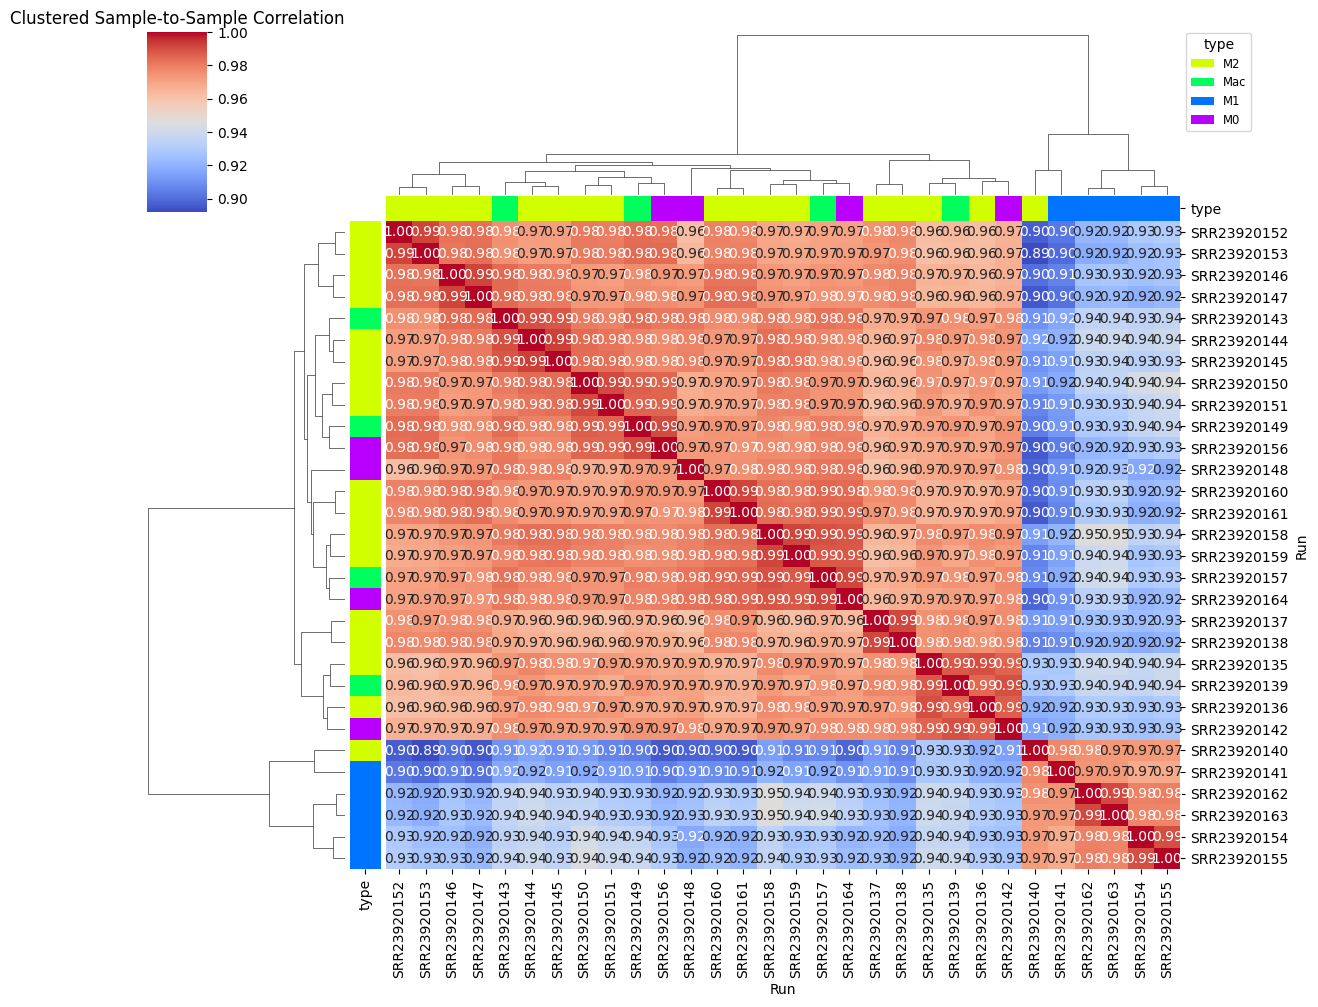

In [32]:

# Prepare metadata for the heatmap annotation
unique_categories = meta_data["type"].unique()
category_colors = sns.color_palette("hsv", len(unique_categories))
color_map = dict(zip(unique_categories, category_colors))
row_colors = meta_data["type"].map(color_map)

# Plot clustered heatmap with metadata annotation
heatmap = sns.clustermap(
    sample_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    figsize=(12, 10),
    row_colors=row_colors,
    col_colors=row_colors
)
plt.title("Clustered Sample-to-Sample Correlation")

# Add legend for categorical variable
for label, color in color_map.items():
    heatmap.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
heatmap.ax_col_dendrogram.legend(
    title="type", bbox_to_anchor=(1, 1), loc='upper left', fontsize='small'
)

plt.show()

Principal component analysis

                   PC1        PC2
Run                              
SRR23920135  -7.924741 -50.992213
SRR23920136 -21.967020 -52.413782
SRR23920137 -30.205108 -40.809093
SRR23920138 -41.473188 -39.530394
SRR23920139  -9.619836 -56.804123


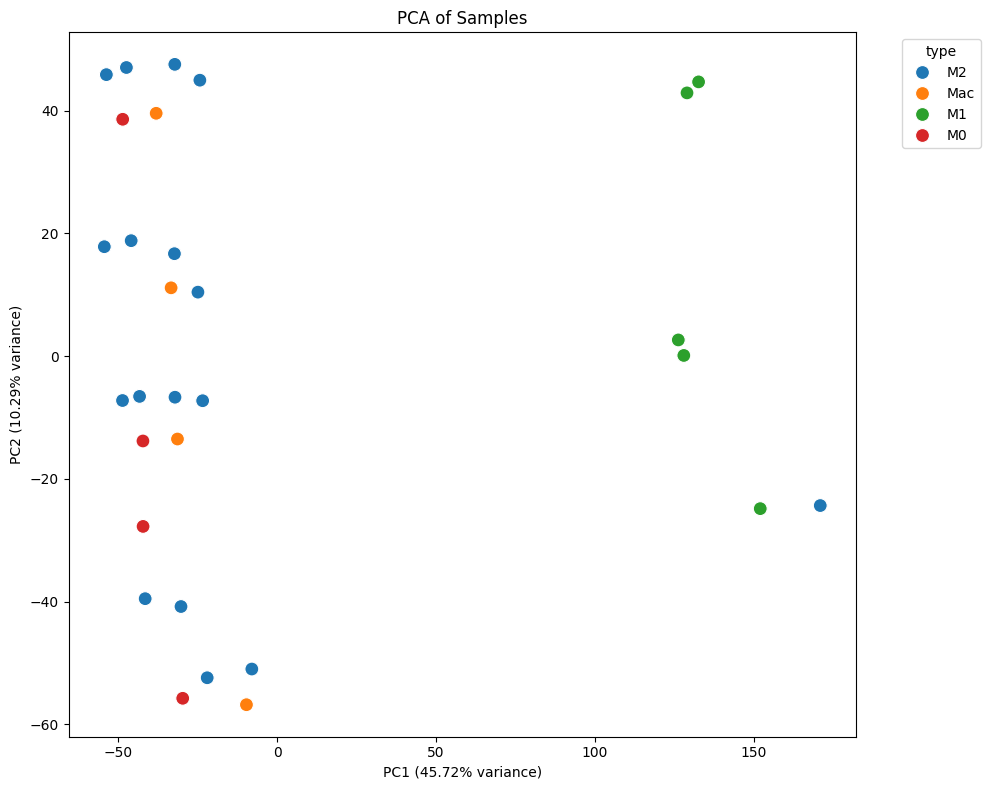

In [35]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(normalized_counts)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=normalized_counts.T.columns)
# Merge with metadata for coloring by category
pca_df = pca_df.merge(meta_data, left_index=True, right_index=True)

# Plot PCA with color-coded categories
plt.figure(figsize=(10, 8))
sns.scatterplot(x="PC1", y="PC2", hue="type", data=pca_df, s=100)
plt.title("PCA of Samples")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.legend(title="type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
ds = DeseqStats(dds, contrast=["condition", "M1", "M2"])
ds.summary()

Running Wald tests...
... done in 7.10 seconds.



Log2 fold change & Wald test p-value: condition M1 vs M2
                     baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                             
ENSG00000000003      9.956286        0.085215  0.538449  0.158260   
ENSG00000000419   1379.172068        0.052771  0.095846  0.550587   
ENSG00000000457    622.457651        1.053680  0.184366  5.715151   
ENSG00000000460    277.491174       -0.246541  0.102493 -2.405445   
ENSG00000000938  17463.998981       -0.123511  0.213993 -0.577175   
...                       ...             ...       ...       ...   
ENSG00000288580      3.384842        0.298171  0.536375  0.555902   
ENSG00000288582     23.761106       -0.031371  0.480049 -0.065349   
ENSG00000288586     40.039772       -0.692699  0.333905 -2.074542   
ENSG00000288587     68.110341        0.221811  0.330343  0.671455   
ENSG00000288588      4.253820        0.894051  0.448107  1.995174   

                       pvalue          padj  

Running Wald tests...
... done in 17.43 seconds.



Log2 fold change & Wald test p-value: condition M1 vs M2
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                       
ENSG00000000003      9.956286        0.085215  0.538449  0.000000  1.000000   
ENSG00000000419   1379.172068        0.052771  0.095846  0.000000  1.000000   
ENSG00000000457    622.457651        1.053680  0.184366  0.885006  0.376153   
ENSG00000000460    277.491174       -0.246541  0.102493  0.000000  1.000000   
ENSG00000000938  17463.998981       -0.123511  0.213993  0.000000  1.000000   
...                       ...             ...       ...       ...       ...   
ENSG00000288580      3.384842        0.298171  0.536375  0.000000  1.000000   
ENSG00000288582     23.761106       -0.031371  0.480049  0.000000  1.000000   
ENSG00000288586     40.039772       -0.692699  0.333905 -1.519587  0.128615   
ENSG00000288587     68.110341        0.221811  0.330343  0.000000  1.00000

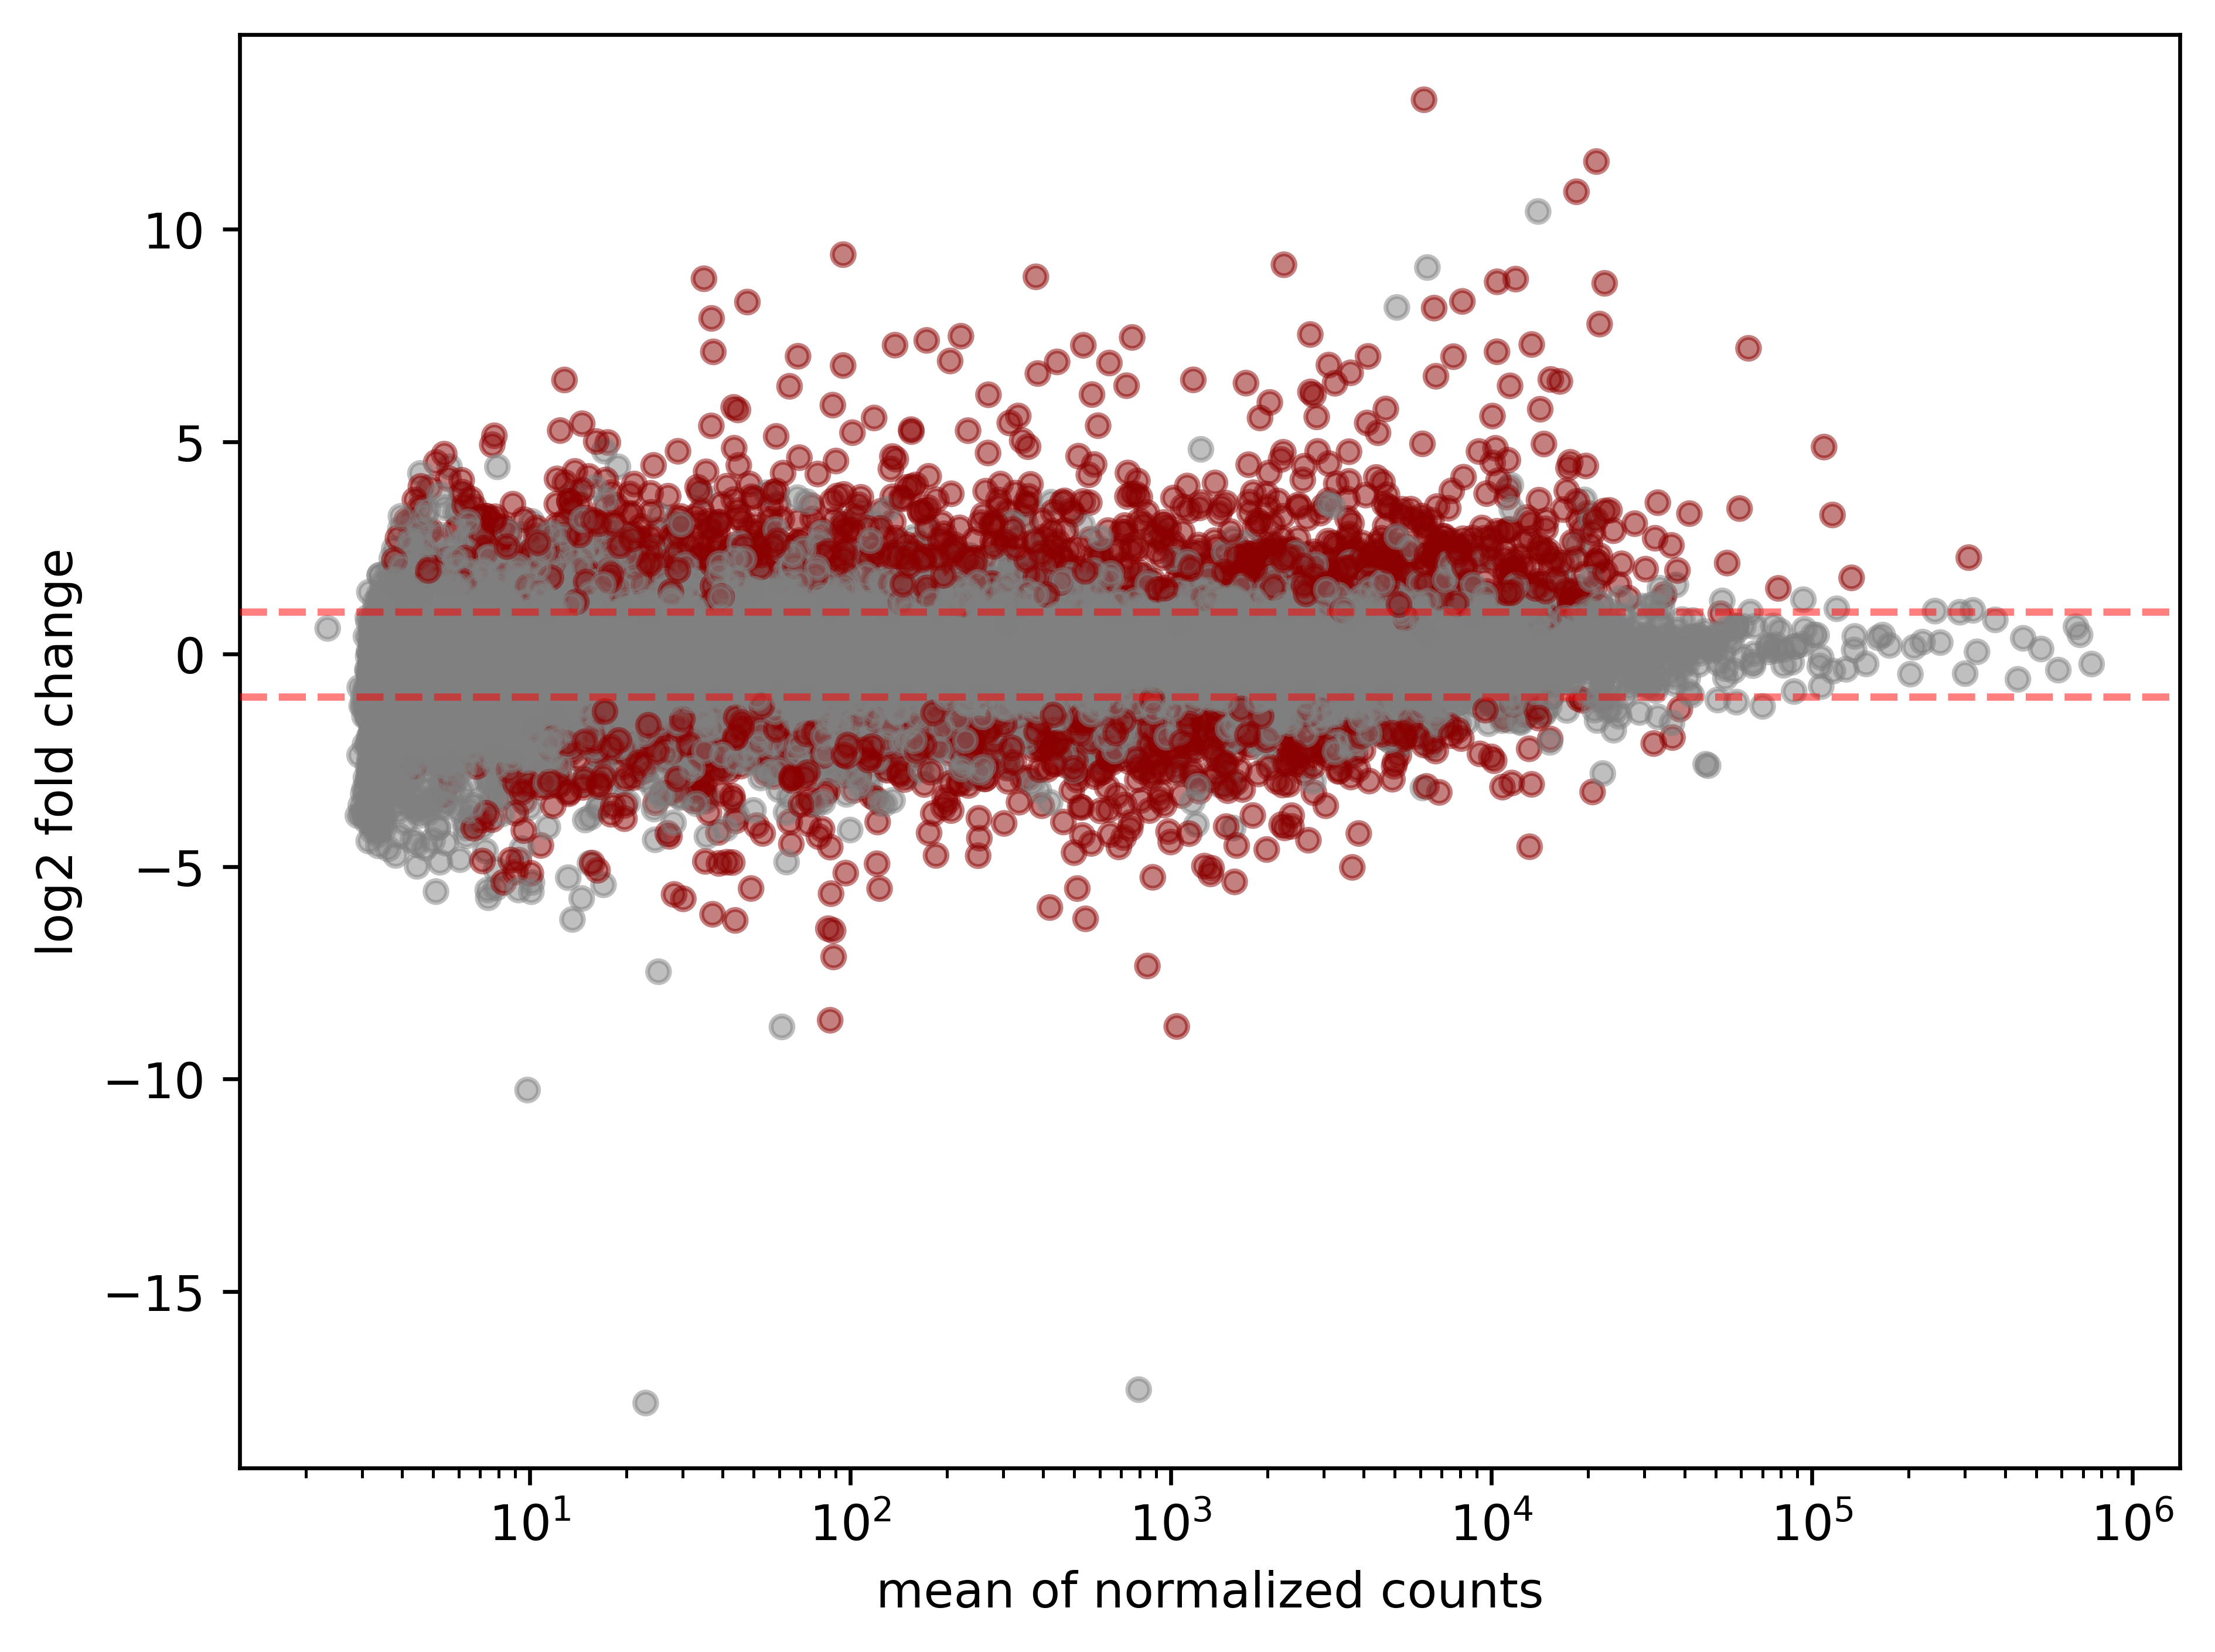

In [24]:
ds.summary(lfc_null=1.0, alt_hypothesis="greaterAbs")
ds.plot_MA(s=20)

In [25]:
ds.results_df


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,9.956286,0.085215,0.538449,0.000000,1.000000,1.000000
ENSG00000000419,1379.172068,0.052771,0.095846,0.000000,1.000000,1.000000
ENSG00000000457,622.457651,1.053680,0.184366,0.885006,0.376153,1.000000
ENSG00000000460,277.491174,-0.246541,0.102493,0.000000,1.000000,1.000000
ENSG00000000938,17463.998981,-0.123511,0.213993,0.000000,1.000000,1.000000
...,...,...,...,...,...,...
ENSG00000288580,3.384842,0.298171,0.536375,0.000000,1.000000,NaN
ENSG00000288582,23.761106,-0.031371,0.480049,0.000000,1.000000,1.000000
ENSG00000288586,40.039772,-0.692699,0.333905,-1.519587,0.128615,0.689273


In [26]:
# Filter significant genes based on adjusted p-value and log2 fold change
significant_genes = ds.results_df[
    (ds.results_df["padj"] < 0.05) &
    (abs(ds.results_df["log2FoldChange"]) > 1.0)]

# Display the filtered significant genes
print(significant_genes)


                     baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                              
ENSG00000000971     33.396337        3.930357  0.486349   6.183651   
ENSG00000002549  24976.423693        1.644200  0.395334   4.159018   
ENSG00000002587    251.907619       -3.860841  0.618201  -3.756195   
ENSG00000003400   1641.824554        2.044330  0.067015  10.332581   
ENSG00000003402  24024.183118        2.906952  0.119311  16.421634   
...                       ...             ...       ...        ...   
ENSG00000288065     17.933251       -2.189507  0.437401  -3.767698   
ENSG00000288156     70.223295       -3.536457  0.611949  -5.779010   
ENSG00000288187     14.862707       -2.061071  0.472263  -3.559632   
ENSG00000288302     17.172905       -1.348386  0.444205  -3.035507   
ENSG00000288380     73.562788       -2.785805  0.488460  -3.671746   

                       pvalue          padj  
gene_id                                    

In [27]:
# Map gene names to the index of significant_genes
significant_genes["gene_name"] = significant_genes.index.map(gene_symbols.to_dict())

# Display the updated DataFrame
print(significant_genes.head())

                     baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                              
ENSG00000000971     33.396337        3.930357  0.486349   6.183651   
ENSG00000002549  24976.423693        1.644200  0.395334   4.159018   
ENSG00000002587    251.907619       -3.860841  0.618201  -3.756195   
ENSG00000003400   1641.824554        2.044330  0.067015  10.332581   
ENSG00000003402  24024.183118        2.906952  0.119311  16.421634   

                       pvalue          padj gene_name  
gene_id                                                
ENSG00000000971  6.263564e-10  3.767241e-08       CFH  
ENSG00000002549  3.196194e-05  7.498352e-04      LAP3  
ENSG00000002587  1.725166e-04  3.211508e-03    HS3ST1  
ENSG00000003400  5.019163e-25  7.216012e-23    CASP10  
ENSG00000003402  1.339107e-60  3.850448e-58     CFLAR  


<ipython-input-27-b43bf45a8a05>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_genes["gene_name"] = significant_genes.index.map(gene_symbols.to_dict())


## Save Results

In [28]:
# Save the filtered significant genes to a CSV file
significant_genes.to_csv("data/significant_genes_filtered.csv", index=False)


## Summary

This workflow covers the following steps:
1. Data loading, processing and normalization.
2. Metadata incorporation.
3. Differential expression analysis using DESeq2.
4. Saving the results.